In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib
import tensorflow as tf

from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Bidirectional, LSTM, GlobalAveragePooling1D
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Add
from tensorflow.keras.layers import Concatenate

from tensorflow.keras.models import Model

# 학습 제어 콜백을 불러온다.
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1787628182.261374   64075 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787628182.263708   64075 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787628182.472531   64075 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787628184.257245   64075 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

In [2]:
# 1. 데이터 설정

# 전체 시뮬레이션 샘플 수를 정의
n_sequences = 4000

# 한 시퀀스의 길이를 정의
seq_len = 60

# 센서 개수를 정의
n_features = 6

# 품질 원인 클래스 수를 정의
n_cause_classes = 4

# 센서 이름을 정의
feature_names = ["temperature", "pressure", "vibration", "current", "speed", "thickness"]


In [3]:
# 2. 시계열 데이터 생성 함수 정의

# 하나의 시퀀스를 생성하는 함수를 정의
def generate_sequence(seq_len, mode, cause_class):
    # 시간축을 0부터 1까지 균등 분할하여 생성
    t = np.linspace(0, 1, seq_len)

    # temperature 기본 패턴을 생성
    temperature = 50 + 3 * np.sin(2 * np.pi * 2 * t) + np.random.normal(0, 0.6, seq_len)

    # pressure 기본 패턴을 생성
    pressure = 100 + 5 * np.cos(2 * np.pi * 1.5 * t) + np.random.normal(0, 0.8, seq_len)

    # vibration 기본 패턴을 생성
    vibration = 10 + 0.5 * np.sin(2 * np.pi * 6 * t) + np.random.normal(0, 0.3, seq_len)

    # current 기본 패턴을 생성
    current = 20 + 1.2 * np.sin(2 * np.pi * 3 * t) + np.random.normal(0, 0.4, seq_len)

    # speed 기본 패턴을 생성
    speed = 1500 + 25 * np.cos(2 * np.pi * 2.5 * t) + np.random.normal(0, 5, seq_len)

    # thickness 기본 패턴을 생성
    thickness = 1.20 + 0.02 * np.sin(2 * np.pi * 1.2 * t) + np.random.normal(0, 0.01, seq_len)

    # 정상 모드가 아니라면 이상 패턴을 삽입
    if mode == "fault":
        # 원인 클래스 0이면 온도와 전류 상승 패턴을 삽입
        if cause_class == 0:
            temperature += np.linspace(0, 10, seq_len)
            current += np.linspace(0, 8, seq_len)

        # 원인 클래스 1이면 압력 급상승과 두께 편차를 삽입
        elif cause_class == 1:
            pressure += np.linspace(0, 18, seq_len)
            thickness += np.linspace(0, 0.10, seq_len)

        # 원인 클래스 2이면 진동 증가와 속도 저하를 삽입
        elif cause_class == 2:
            vibration += np.linspace(0, 6, seq_len)
            speed -= np.linspace(0, 160, seq_len)

        # 원인 클래스 3이면 복합 이상 패턴을 삽입
        elif cause_class == 3:
            temperature += np.linspace(0, 6, seq_len)
            pressure += np.linspace(0, 10, seq_len)
            vibration += np.linspace(0, 3, seq_len)
            current += np.linspace(0, 4, seq_len)

    # 생성된 각 센서를 열 방향으로 쌓아 하나의 2차원 시퀀스로 만듬
    sequence = np.column_stack([temperature, pressure, vibration, current, speed, thickness])

    # 생성된 시퀀스를 반환
    return sequence

In [4]:
# 3. 전체 데이터셋 설정
# 입력 시퀀스를 저장할 리스트를 생성
X_list = []

# 고장 여부 라벨을 저장할 리스트를 생성
y_fault_list = []

# 원인 클래스 라벨을 저장할 리스트를 생성
y_cause_list = []

# 전체 샘플 수만큼 반복
for i in range(n_sequences):
    mode = np.random.choice(["normal", "fault"], p=[0.7, 0.3])  # 70%는 정상, 30%는 이상이 되도록 랜덤하게 모드를 선택

    if mode == "normal":
        cause_class = 0
        
    # 이상일 경우 1~3 중 하나를 원인 클래스로 사용
    else:
        cause_class = np.random.choice([1, 2, 3])

    # 시퀀스를 생성
    seq = generate_sequence(seq_len=seq_len, mode=mode, cause_class=cause_class)

    # 입력 리스트에 시퀀스를 추가
    X_list.append(seq)

    # 고장 여부 라벨을 추가, 정상은 0, 이상은 1
    y_fault_list.append(0 if mode == "normal" else 1)

    # 원인 클래스 라벨을 추가
    y_cause_list.append(cause_class)

# 입력 리스트를 numpy 배열로 변환
X = np.array(X_list)

# 고장 여부 라벨을 numpy 배열로 변환
y_fault = np.array(y_fault_list)

# 원인 클래스 라벨을 numpy 배열로 변환
y_cause = np.array(y_cause_list)

# 고장 여부 라벨 shape를 출력
print("y_fault shape:", y_fault.shape)
# 원인 라벨 shape를 출력
print("y_cause shape:", y_cause.shape)
# 고장 여부 클래스 분포를 출력
print("Fault label distribution:\n", pd.Series(y_fault).value_counts().sort_index())
# 원인 클래스 분포를 출력
print("Cause label distribution:\n", pd.Series(y_cause).value_counts().sort_index())

y_fault shape: (4000,)
y_cause shape: (4000,)
Fault label distribution:
 0    2800
1    1200
Name: count, dtype: int64
Cause label distribution:
 0    2800
1     395
2     387
3     418
Name: count, dtype: int64


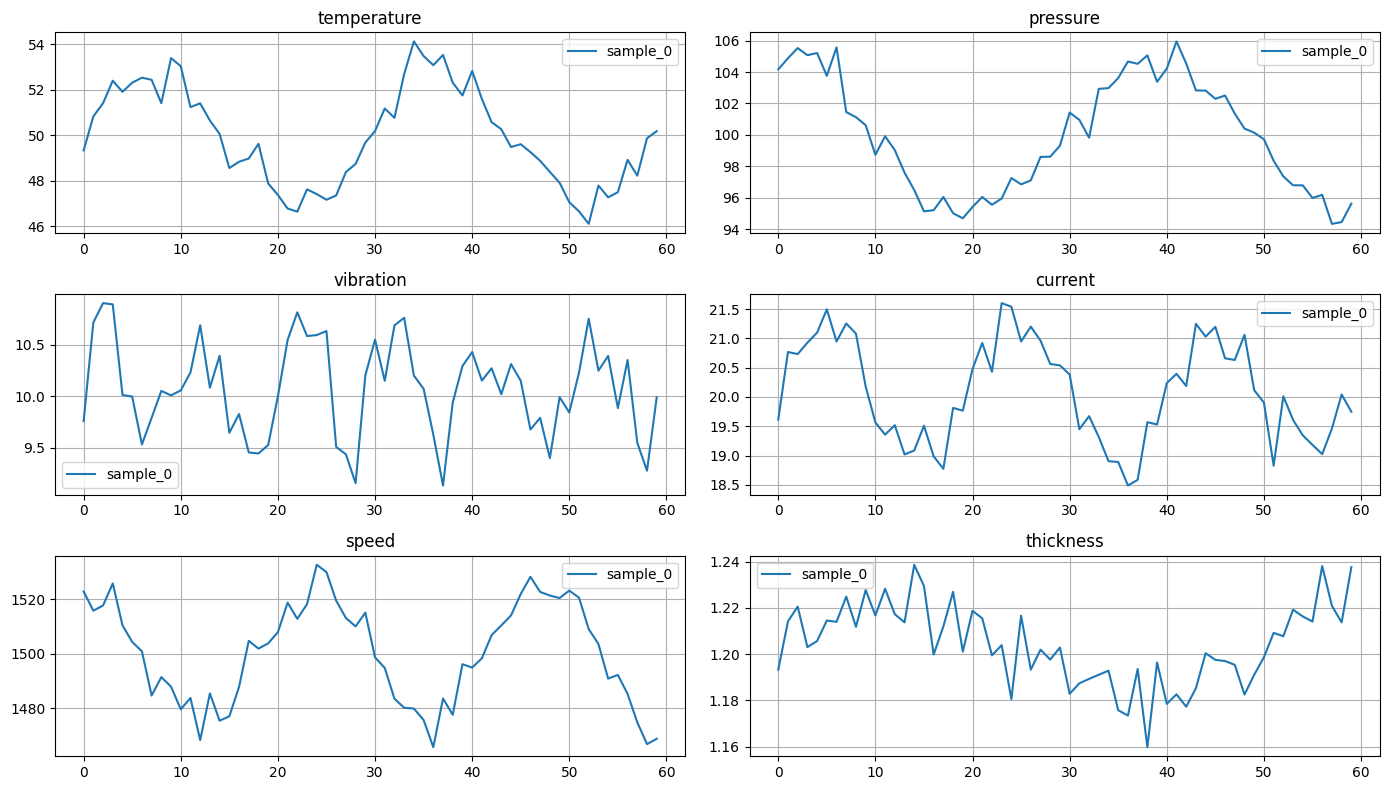

In [5]:
# 4. 시퀀스 데이터 시각화

plt.figure(figsize=(14,8))

# 각 센서별로 subplot을 생성
for idx in range(n_features):
  # 3열 2행 구조의 subplot을 생성
  plt.subplot(3,2, idx + 1)

  # 첫 번째 정상 샘플의 해당 센서 시퀀스를 표시
  plt.plot(X[0, :, idx], label="sample_0")
  plt.title(feature_names[idx])
  plt.legend()
  plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
# 5. 합습/검증/테스트 데이터 분리

X_train, X_temp, y_fault_train, y_fault_temp, y_cause_train, y_cause_temp = train_test_split(
  X, y_fault, y_cause, test_size=0.2, random_state=42, stratify=y_fault
)

# 임시 데이터를 검증용과 테스트용으로  분리
X_val, X_test, y_fault_val, y_fault_test, y_cause_val, y_cause_test = train_test_split(
  X_temp, y_fault_temp, y_cause_temp, test_size=0.5, random_state=42, stratify=y_fault_temp
)

# 분리 결과 shape를 출력
print("Train:", X_train.shape, y_fault_train.shape, y_cause_train. shape)
print("Val :", X_val.shape, y_fault_val.shape, y_cause_val.shape)
print("Test :", X_test. shape, y_fault_test. shape, y_cause_test. shape)

Train: (3200, 60, 6) (3200,) (3200,)
Val : (400, 60, 6) (400,) (400,)
Test : (400, 60, 6) (400,) (400,)


In [7]:
# 6. 시계열 데이터 정규화
"""
시계열 데이터 : 3차원 (sample, timestamps, features) 으로 보통 구성됨
시계열 데이터 3차원 -> 스케일러 적용을 위해 2차원으로 펼쳐야 함
"""
# 먼저 StandardScaler 객체를 생성
scaler = StandardScaler()

# 학습 데이터를 (샘플*시점, 센서수) 형태로 reshape
X_train_2d = X_train.reshape(-1, n_features)

# 검증 데이터를 2차원으로 reshape
X_val_2d = X_val.reshape(-1, n_features)

# 테스트 데이터를 2차원으로 reshape
X_test_2d = X_test.reshape(-1, n_features)

# 학습 데이터 기준으로 스케일러를 학습하고 변환
X_train_scaled_2d = scaler.fit_transform(X_train_2d)

# 검증 데이터를 동일 스케일러로 변환
X_val_scaled_2d = scaler.transform(X_val_2d)

# 테스트 데이터를 동일 스케일러로 변환
X_test_scaled_2d = scaler.transform(X_test_2d)

# 다시 원래의 3차원 시계열 형태로 복원
X_train_scaled = X_train_scaled_2d.reshape(-1, seq_len, n_features)

# 검증 데이터도 3차원으로 복원
X_val_scaled = X_val_scaled_2d.reshape(-1, seq_len, n_features)

# 테스트 데이터도 3차원으로 복원
X_test_scaled = X_test_scaled_2d.reshape(-1, seq_len, n_features)

In [10]:
# 7. 멀티태스크 모델 구성
"""
구조:
입력 -> Conv1D -> Pooling -> BiLSTM -> Self-Attention -> Dense
    -> 출력1: fault_output (이진분류)
    -> 출력2: cause_output (멀티 클래스 분류)
"""

# 입력 레이어 정의
inputs = Input(shape=(seq_len, n_features), name='sensor_input')

# 첫 번째 1D CNN 레이어를 적용해서 기본적인 패턴 추출
x = Conv1D(filters=64, kernel_size=3, padding='same', activation='relu', name="conv1")(inputs)
x = Dropout(0.2, name="dropout_conv1")(x)

# 두 번째 1D CNN 레이어를 적용해서 조금 더 복잡한 패턴 추출
x = Conv1D(filters=64, kernel_size=3, padding="same", activation="relu", name="conv2")(x)
x = MaxPooling1D(pool_size=2, name="maxpool1")(x)

# 양방향 LSTM을 적용해서 과거와 현재 미래의 연결성을 반영
x = Bidirectional(LSTM(64, return_sequences=True), name="bilstm")(x)

# Selt-Attension 적용
# 1) selt-attension 적용 위한 정규화
attn_input = LayerNormalization(name="attn_norm1")(x)

# 2) 멀티헤드 어텐션 적용 <- 데이터의 중요한 시점 간의 관계를 학습  <- 좀더 다양한 패턴 학습(표현력 향상)
attn_input = MultiHeadAttention(num_heads=4, key_dim=32, name="multihead_attention")(attn_input, attn_input)

# 잔차 연결을 통해 원본의 특징과 어텐션 결과 더해줌
x = Add(name="attn_residual")([x, attn_input])

# 다시 정규화 수행
x = LayerNormalization(name="attn_norm2")(x)

# 시계열의 전체 정보를 요약하기 위한 GLobalAveragePooling1D 적용
x = GlobalAveragePooling1D(name="global_avg_pool")(x)

# 공통 표현 학습용 Dense 레이어 추가
shared = Dense(128, activation="relu", name="shared_dense1")(x)
shared = Dropout(0.3, name="shared_dropout1")(shared)

# 고장 여부 예측용 분류기 Densce 레이어 정의
fault_branch = Dense(32, activation="relu", name="fault_dense")(shared)

# 고장 여부 이진분류를 위한 출력층 정의
fault_output = Dense(1, activation="sigmoid", name="fault_output")(fault_branch)

# 원인 분류용 분류기 Densce 레이어 정의
cause_branch = Dense(32, activation="relu", name="cause_dense")(shared)

# 원인 멀티클래스 분류 출력층 정의
cause_output = Dense(n_cause_classes, activation="softmax", name="cause_output")(cause_branch)

# 멀티출력 모델 생성
model = Model(inputs=inputs, outputs=[fault_output, cause_output],
              name="predictive_maintenance_multitask_model")

# 모델 요약
model.summary()




Model: "predictive_maintenance_multitask_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 60, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 60, 64)    │      1,216 │ sensor_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_conv1       │ (None, 60, 64)    │          0 │ conv1[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 60, 64)    │     12,352 │ dropout_conv1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1            │ (None, 30, 64)    │          0 │ conv2[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 30, 128)   │     66,048 │ maxpool1[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_norm1          │ (None, 30, 128)   │        256 │ bilstm[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multihead_attention │ (None, 30, 128)   │     66,048 │ attn_norm1[0][0], │
│ (MultiHeadAttentio… │                   │            │ attn_norm1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_residual (Add) │ (None, 30, 128)   │          0 │ bilstm[0][0],     │
│                     │                   │            │ multihead_attent… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_norm2          │ (None, 30, 128)   │        256 │ attn_residual[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 128)       │          0 │ attn_norm2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense1       │ (None, 128)       │     16,512 │ global_avg_pool[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout1     │ (None, 128)       │          0 │ shared_dense1[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fault_dense (Dense) │ (None, 32)        │      4,128 │ shared_dropout1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cause_dense (Dense) │ (None, 32)        │      4,128 │ shared_dropout1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fault_output        │ (None, 1)         │         33 │ fault_dense[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cause_output        │ (None, 4)         │        132 │ cause_dense[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 171,109 (668.39 KB)

 Trainable params: 171,109 (668.39 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 8. 모델 컴파일
model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
  loss={
    "fault_output" : "binary_crossentropy",
    "cause_output" : "sparse_categorical_crossentropy"
  },
  loss_weights={
    "fault_output" : 1.0,
    "cause_output" : 1.0
  },
  metrics={
    "fault_output" : ["accuracy"],
    "cause_output" : ["accuracy"]
  }
)

In [12]:
# 9. 콜백 설정
# 검증 손실이 개선되 않으면 학습을 조기 종료하는 콜백정의
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# 검증 손실이 정체시, 학습률을 감소시키는 콜백정의
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# 가장 좋은 모델을 파일로 저장하는 콜백 정의
checkpoint = ModelCheckpoint(
    filepath="best_multitask_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [13]:
# 10. 모델 학습
# 모델을 학습하고 학습 이력을 history 객체에 저장
history = model.fit(
    X_train_scaled,
    {
        "fault_output": y_fault_train,
        "cause_output": y_cause_train
    },
    validation_data=(
        X_val_scaled,
        {
            "fault_output": y_fault_val,
            "cause_output": y_cause_val
        }
    ),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - cause_output_accuracy: 0.9544 - cause_output_loss: 0.1572 - fault_output_accuracy: 0.9756 - fault_output_loss: 0.0669 - loss: 0.2242 - val_cause_output_accuracy: 1.0000 - val_cause_output_loss: 1.4661e-04 - val_fault_output_accuracy: 1.0000 - val_fault_output_loss: 1.2672e-04 - val_loss: 2.6843e-04 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - cause_output_accuracy: 1.0000 - cause_output_loss: 3.8531e-04 - fault_output_accuracy: 1.0000 - fault_output_loss: 1.6748e-04 - loss: 5.5279e-04 - val_cause_output_accuracy: 1.0000 - val_cause_output_loss: 2.8586e-05 - val_fault_output_accuracy: 1.0000 - val_fault_output_loss: 2.1552e-05 - val_loss: 4.8372e-05 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - cause_output_accuracy: 1.0000 - cause_output_loss: 2.1508e-04 - fault_output_accuracy: 1.0000 - fault_output_loss: 7.2369e-05 - loss: 2.8745e-04 - val_cause_output_accuracy: 1.0000 

In [14]:
# 11. 학습과정 시각화
# 테스트 데이터에서 모델 성능을 평가
eval_result = model.evaluate(
    X_test_scaled,
    {
        "fault_output": y_fault_test,
        "cause_output": y_cause_test
    },
    verbose=0
)

# 평가 결과를 출력
print("Evaluation Result:", eval_result)

Evaluation Result: [4.2180991499662923e-07, 2.590492726994853e-07, 1.6677836356393527e-07, 1.0, 1.0]


In [15]:
# 12. 테스트 데이터 예측

# 테스트  데이터 예측 수행
fault_prob_test, cause_prob_test = model.predict(X_test_scaled)

# 고장 여부 확률을 0 또는 1 클래스로 변환
fault_pred_test = (fault_prob_test.flatten() >= 0.5).astype(int)

# 원인 클래스는 가장 큰 확률을 선택하는 argmax 적용
cause_pred_test = np.argmax(cause_prob_test, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [16]:
# 13. 성능 출력 - 고장 여부 (이진분류)
# 고장 여부 정확도 계산
fault_acc = accuracy_score(y_fault_test, fault_pred_test)

# Confusion Matrix 계산
fault_cm = confusion_matrix(y_fault_test, fault_pred_test)

# 고장 여부 정확도 출력
print("\n[고장 여부 이진분류 성능]")
print("Accuracy:", fault_acc)

# 고장 여부 Confusion Matrix 출력
print("Confusion Matrix:\n", fault_cm)

# 고장 여부 분류 리포트 출력
print("Classification Report:\n", classification_report(y_fault_test, fault_pred_test))


[고장 여부 이진분류 성능]
Accuracy: 1.0
Confusion Matrix:
 [[280   0]
 [  0 120]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       280
           1       1.00      1.00      1.00       120

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [17]:
# 14. 성능 출력 - 원인분류(멀티클래스 분류)
# 원인 분류 정확도 계산
cause_acc = accuracy_score(y_cause_test, cause_pred_test)

# 원인 분류 confusion_matrix 계산
cause_cm = confusion_matrix(y_cause_test, cause_pred_test)

# 원인 분류 정확도 출력
print("\n[원인 멀티클래스 분류 성능]")
print("Accuracy:", cause_acc)

# 원인 분류 confusion_matrix 출력
print("Confusion Matrix:\n", cause_cm)

# 원인 분류 리포트 출력
print("Classification Report:\n", classification_report(y_cause_test, cause_pred_test))


[원인 멀티클래스 분류 성능]
Accuracy: 1.0
Confusion Matrix:
 [[280   0   0   0]
 [  0  30   0   0]
 [  0   0  38   0]
 [  0   0   0  52]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       280
           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00        38
           3       1.00      1.00      1.00        52

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [18]:
# 15. 모델/스케일러/학습 이력 저장
# 전체 모델을 파일로 저장
model.save("final_multitask_model.keras")

# 스케일러를 파일로 저장
joblib.dump(scaler, "timeseries_scaler.pkl")

# 학습 이력을 데이터프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습 이력을 CSV 파일로 저장
history_df.to_csv("training_history.csv", index=False)

# 저장 완료 메시지를 출력
print("모델, 스케일러, 학습 이력 저장 완료")

모델, 스케일러, 학습 이력 저장 완료


In [19]:
# 16. 저장된 모델/스케일러 불러오기
# 저장된 모델을 다시 불러오기
loaded_model = tf.keras.models.load_model("final_multitask_model.keras")

# 저장된 스케일러를 다시 불러오기
loaded_scaler = joblib.load("timeseries_scaler.pkl")

# 저장된 학습 이력을 다시 불러오기
loaded_history_df = pd.read_csv("training_history.csv")

# 불러온 학습 이력 일부를 출력
print(loaded_history_df.head())

   cause_output_accuracy  cause_output_loss  fault_output_accuracy  \
0               0.954375           0.157230               0.975625   
1               1.000000           0.000385               1.000000   
2               1.000000           0.000215               1.000000   
3               1.000000           0.000138               1.000000   
4               1.000000           0.000089               1.000000   

   fault_output_loss      loss  val_cause_output_accuracy  \
0           0.066927  0.224158                        1.0   
1           0.000167  0.000553                        1.0   
2           0.000072  0.000287                        1.0   
3           0.000056  0.000194                        1.0   
4           0.000034  0.000123                        1.0   

   val_cause_output_loss  val_fault_output_accuracy  val_fault_output_loss  \
0               0.000147                        1.0               0.000127   
1               0.000029                        1.0     

In [20]:
# 17. 신규데이터 생성
# 신규 샘플 시퀀스 데이터를 저장할 리스트 생성
new_sequences = []

# 첫 번째 신규 샘플은 정상 패턴으로 생성
new_sequences.append(generate_sequence(seq_len=seq_len, mode="normal", cause_class=0))

# 두 번째 신규 샘플은 원인1 유형의 이상 패턴으로 생성
new_sequences.append(generate_sequence(seq_len=seq_len, mode="fault", cause_class=1))

# 세 번째 신규 샘플은 원인2 유형의 이상 패턴으로 생성
new_sequences.append(generate_sequence(seq_len=seq_len, mode="fault", cause_class=2))

# 신규 샘플을 numpy 배열로 변환
new_sequences = np.array(new_sequences)

# 신규 데이터를 2차원으로 펼침 (시계열 데이터 3차원, 정규화는 2차원 필요)
new_sequences_2d = new_sequences.reshape(-1, n_features)

# 저장된 스케일러로 변환
new_sequences_scaled_2d = loaded_scaler.transform(new_sequences_2d)

# 다시 3차원 시계열 형태로 복원 (모델은 3차원으로 인식 필요)
new_sequences_scaled = new_sequences_scaled_2d.reshape(-1, seq_len, n_features)

In [21]:
# 18. 신규데이터 예측
# 불러온 모델로 신규 데이터 예측
new_fault_prob, new_cause_prob = loaded_model.predict(new_sequences_scaled)

# 고장 여부 최종 예측값 계산
new_fault_pred = (new_fault_prob.flatten() >= 0.5).astype(int)

# 원인 클래스 최종 예측값 계산
new_cause_pred = np.argmax(new_cause_prob, axis=1)

# 결과를 저장할 리스트 생성
prediction_rows = []

# 각 신규 샘플별 예측 결과 순회
for i in range(len(new_sequences)):
    # 한 샘플의 결과를 딕셔너리 형태로 정리
    row = {
        "sample_id": i + 1,
        "fault_probability": float(new_fault_prob[i][0]),
        "fault_prediction": int(new_fault_pred[i]),
        "cause_prediction": int(new_cause_pred[i]),
        "cause_prob_class_0": float(new_cause_prob[i][0]),
        "cause_prob_class_1": float(new_cause_prob[i][1]),
        "cause_prob_class_2": float(new_cause_prob[i][2]),
        "cause_prob_class_3": float(new_cause_prob[i][3]),
    }

    # 결과 리스트에 예측결과 추가
    prediction_rows.append(row)

    # 화면에 결과 출력
    print(f"\n[신규 샘플 {i+1}]")
    print("고장 확률:", float(new_fault_prob[i][0]))
    print("고장 예측:", int(new_fault_pred[i]))
    print("원인 예측:", int(new_cause_pred[i]))
    print("원인별 확률:", new_cause_prob[i])

# 예측 결과 Log 이력 생성
# 예측 결과를 데이터프레임으로 변환
prediction_df = pd.DataFrame(prediction_rows)

# 예측 결과를 CSV 파일로 저장
prediction_df.to_csv("new_data_predictions.csv", index=False)

# 저장된 예측 결과를 출력
print("\n신규 데이터 예측 결과")
print(prediction_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step

[신규 샘플 1]
고장 확률: 7.2850192545104164e-09
고장 예측: 0
원인 예측: 0
원인별 확률: [1.0000000e+00 2.6745816e-08 4.8469229e-08 4.4720642e-12]

[신규 샘플 2]
고장 확률: 0.9999997019767761
고장 예측: 1
원인 예측: 1
원인별 확률: [1.1111209e-07 9.9999940e-01 3.6073106e-07 9.6855835e-08]

[신규 샘플 3]
고장 확률: 0.9999994039535522
고장 예측: 1
원인 예측: 2
원인별 확률: [1.0114188e-07 2.1420109e-07 9.9999940e-01 2.5528971e-07]

신규 데이터 예측 결과
   sample_id  fault_probability  fault_prediction  cause_prediction  \
0          1       7.285019e-09                 0                 0   
1          2       9.999997e-01                 1                 1   
2          3       9.999994e-01                 1                 2   

   cause_prob_class_0  cause_prob_class_1  cause_prob_class_2  \
0        1.000000e+00        2.674582e-08        4.846923e-08   
1        1.111121e-07        9.999994e-01        3.607311e-07   
2        1.011419e-07        2.142011e-07        9.999994e-01   

   cause_prob_class_3  
0        4

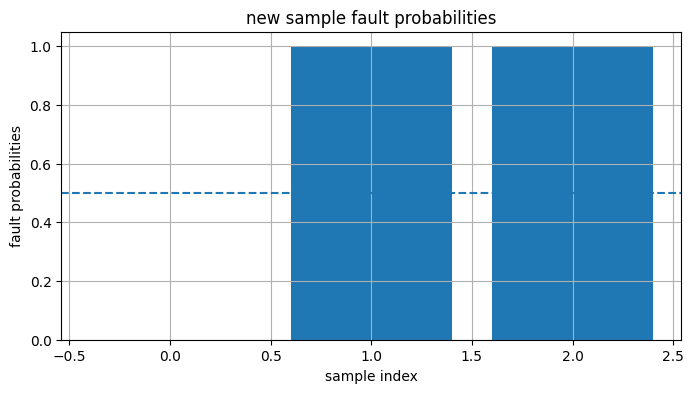

In [22]:
# 19. 신규데이터 예측 시각화 (1.이진분류 이상감지 예측 결과 시각화)
 
plt.figure(figsize=(8,4))
plt.bar(range(len(new_fault_prob)), new_fault_prob.flatten())

# 기준선 0.5표시
plt.axhline(0.5, linestyle="--")

plt.title("new sample fault probabilities")
plt.xlabel("sample index")
plt.ylabel("fault probabilities")
plt.grid(True)
plt.show()

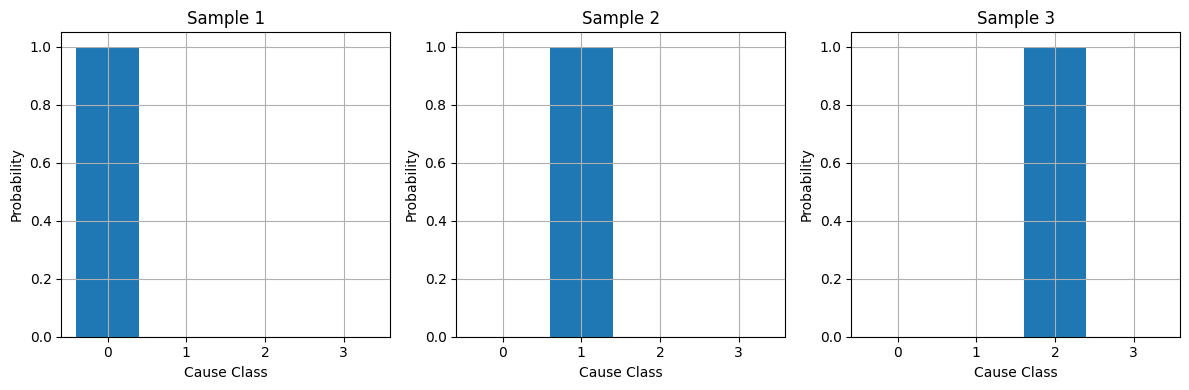

In [23]:
# 19. 신규데이터 예측 시각화(2.멀티클래스 원인분류 예측 결과 시각화)
plt.figure(figsize=(12, 4))

# 신규 샘플 수만큼 반복
for i in range(len(new_cause_prob)):
    # 1행 N열 구조로 subplot을 생성
    plt.subplot(1, len(new_cause_prob), i + 1)

    # 해당 샘플의 원인 클래스 확률 막대그래프
    plt.bar(range(n_cause_classes), new_cause_prob[i])

    plt.title(f"Sample {i+1}")
    plt.xlabel("Cause Class")
    plt.ylabel("Probability")

    # x축 눈금 설정
    plt.xticks(range(n_cause_classes))
    plt.grid(True)

plt.tight_layout()
plt.show()